# ASTRA Workbench

In [1]:
import astra
import matplotlib.pyplot as plt
import numpy as np
import sys 
sys.path.append('..\\')
import amglib.readers as rd
import amglib.imageutils as amg
import amglib.widgets as aw

from tqdm.notebook import tqdm

from scipy.ndimage import shift

from amglib.golden_sequence import golden_sequence
import importlib

In [2]:
importlib.reload(rd)
importlib.reload(aw)

<module 'amglib.widgets' from 'C:\\Users\\kaestner\\git\\scripts\\python\\astra\\..\\amglib\\widgets.py'>

## Check ASTRA

In [3]:
astra.test()

ASTRA Toolbox v2.5.0
Getting GPU info... GPU #0: NVIDIA RTX A4000, with 16375MB, CUDA compute capability 8.6
Testing basic CPU 2D functionality... Ok
Testing basic CUDA 2D functionality... Ok
Testing basic CUDA 3D functionality... Ok


## Load and prepare data

In [4]:
path = 'D:\\Kaestner\\HeatTomo\\transfer_391249_files_bf605696\\Neutronen\\convert\\4NBSG3\\'

In [5]:
#proj = rd.read_images('C:\\Users\\antoni_c\\DATA\\P20250668\\02_rawdata\\01_Config1\\01_Calibration\\cal_{0:05d}.fits',first=1, last=361)

proj0 = rd.read_images(path + 'silicaT_{0:05d}.fits',first=1, last=359)

  0%|          | 0/359 [00:00<?, ?it/s]

In [6]:
#obselect = aw.FileSelector()
#obselect.display()

In [7]:
#ob = rd.read_images('C:\\Users\\antoni_c\\DATA\\P20250668\\02_rawdata\\01_Config1\\01_Calibration\\ob_{0:05d}.fits',first=1, last=5).mean(axis=0)
ob0 = rd.read_images(path + 'ob_{0:05d}.fits',first=1, last=10).mean(axis=0)

  0%|          | 0/10 [00:00<?, ?it/s]

In [8]:
#dcselect = aw.FileSelector()
#dcselect.display()

In [9]:
#dc = rd.read_images('C:\\Users\\antoni_c\\DATA\\P20250668\\02_rawdata\\01_Config1\\01_Calibration\\dc_{0:05d}.fits',first=1, last=5).mean(axis=0)
dc = rd.read_images(path+'dc_{0:05d}.fits',first=1, last=10).mean(axis=0)

  0%|          | 0/10 [00:00<?, ?it/s]

### Normalize

In [10]:
p = amg.normalizeImage(img=proj0,ob=ob0,dc=dc,neglog=True)
p.shape

100%|██████████| 359/359 [00:24<00:00, 14.58it/s]


(359, 2048, 2048)

In [11]:
p = amg.morph_spot_clean(p[:,1000:1100,:])

(359, 2048)


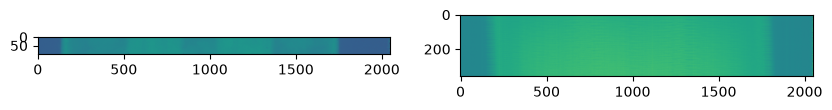

In [12]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(p[0])
orig_sino = p[:,p.shape[1]//2,:]
ax[1].imshow(orig_sino)
print(orig_sino.shape)


In [13]:
idx = np.arange(359)
theta = golden_sequence(idx)

idx180 = np.argmax(theta)
print(idx180,theta[idx180])

144 179.44098839727667


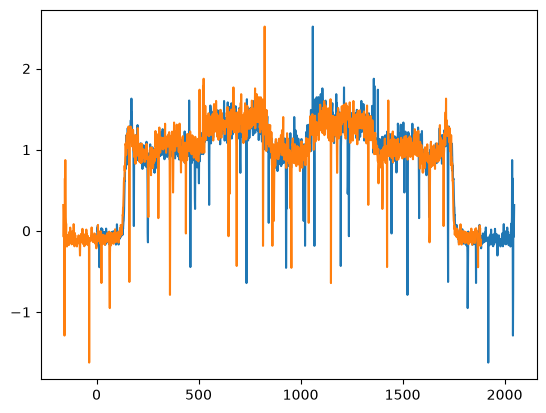

In [14]:
x = np.arange(2048)
plt.plot(x,p[0,1000,:])
plt.plot(x-163,p[0,1000,::-1])

## The reconstruction

In [34]:
import numpy as np
import astra
from skimage.restoration import denoise_tv_chambolle
from bm3d import bm3d

def reconstruct_sirt_tv(
    sinogram,
    angles,
    image_size=None,
    detector_spacing=1.0,
    center_offset=0.0,   # detector pixels
    n_outer=20,
    sirt_steps=5,
    tv_weight=0.002,
    tv_iterations = 10,
    initial = None
):
    sinogram = np.asarray(sinogram, dtype=np.float32)
    angles = np.asarray(angles, dtype=np.float32)

    n_angles, n_detectors = sinogram.shape

    if len(angles) != n_angles:
        raise ValueError(
            f"{len(angles)=} does not match sinogram.shape[0]={n_angles}"
        )

    if image_size is None:
        image_size = n_detectors

    # Reconstruction geometry
    vol_geom = astra.create_vol_geom(
        image_size,
        image_size
    )

    # Standard parallel-beam geometry
    proj_geom = astra.create_proj_geom(
        'parallel',
        detector_spacing,
        n_detectors,
        angles
    )

    # Shift detector relative to rotation axis.
    # center_offset is specified in detector pixels.
    proj_geom = astra.geom_postalignment(
        proj_geom,
        center_offset
    )

    sino_id = astra.data2d.create(
        '-sino',
        proj_geom,
        sinogram
    )

    rec_id = astra.data2d.create(
        '-vol',
        vol_geom,
        0.0
    )

    cfg = astra.astra_dict('SIRT_CUDA')
    cfg['ProjectionDataId'] = sino_id
    cfg['ReconstructionDataId'] = rec_id
    cfg['option'] = {
        'MinConstraint': 0.0
    }

    alg_id = astra.algorithm.create(cfg)
    
    if initial is not None :
         astra.data2d.store(
            rec_id,
            initial.astype(np.float32)
        )

    try:
        for k in tqdm(range(n_outer)):

            # Data fidelity
            astra.algorithm.run(
                alg_id,
                sirt_steps
            )

            reconstruction = astra.data2d.get(rec_id)

            # TV regularization
            reconstruction = denoise_tv_chambolle(
                reconstruction,
                weight=tv_weight,
                max_num_iter=tv_iterations,
                eps=1e-3,
                channel_axis=None
            )

#            reconstruction = bm3d(reconstruction,sigma_psd=0.001)

            reconstruction = np.maximum(
                reconstruction,
                0.0
            )

            astra.data2d.store(
                rec_id,
                reconstruction.astype(np.float32)
            )

        reconstruction = astra.data2d.get(rec_id)

    finally:
        astra.algorithm.delete(alg_id)
        astra.data2d.delete(sino_id)
        astra.data2d.delete(rec_id)

    return reconstruction

  0%|          | 0/5 [00:00<?, ?it/s]

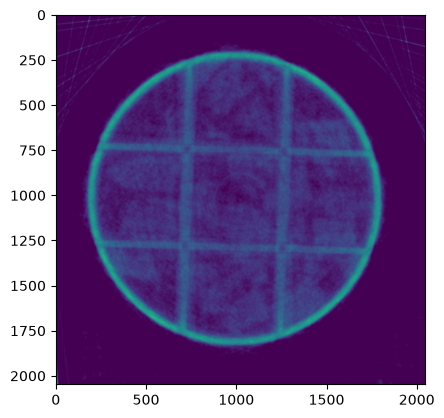

In [43]:
ndir = 50
sinogram = p[:ndir,p.shape[1]//2,:]

angles_rad = np.deg2rad(theta[:ndir]+11)
center_offset = 49

recon50 = reconstruct_sirt_tv(
    sinogram,
    angles_rad,
    center_offset=center_offset,
    n_outer=5,
    sirt_steps=20,
    tv_weight=0.002,
    tv_iterations = 10
#     initial = recon350
)

plt.imshow(recon50,vmin=0,vmax=0.005)

  0%|          | 0/5 [00:00<?, ?it/s]

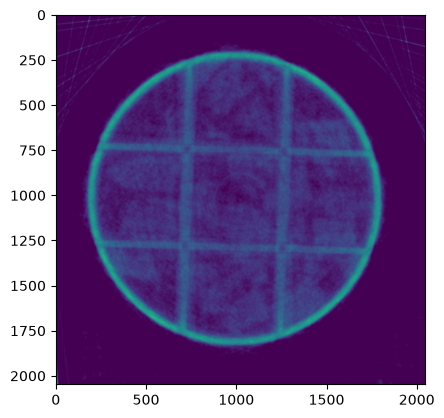

In [46]:
ndir = 25
sinogram = p[:ndir,p.shape[1]//2,:]

angles_rad = np.deg2rad(theta[:ndir]+11)
center_offset = 49

recon25 = reconstruct_sirt_tv(
    sinogram,
    angles_rad,
    center_offset=center_offset,
    n_outer=5,
    sirt_steps=20,
    tv_weight=0.002,
    tv_iterations = 10
#     initial = recon350
)

plt.imshow(recon50,vmin=0,vmax=0.005)

  0%|          | 0/5 [00:00<?, ?it/s]

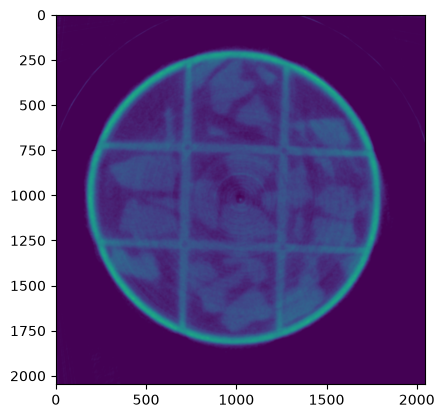

In [41]:
ndir = 350
sinogram = p[:ndir,p.shape[1]//2,:]

angles_rad = np.deg2rad(theta[:ndir]+11)
center_offset = 49

recon350 = reconstruct_sirt_tv(
    sinogram,
    angles_rad,
    center_offset=center_offset,
    n_outer=5,
    sirt_steps=20,
    tv_weight=0.002,
    tv_iterations = 10
)

plt.imshow(recon350,vmin=0,vmax=0.005)

In [54]:
ndirs = [25,50,100,350]

recons = []
for ndir in ndirs:
    sinogram = p[:ndir,p.shape[1]//2,:]

    angles_rad = np.deg2rad(theta[:ndir]+11)
    center_offset = 49

    recon = reconstruct_sirt_tv(
        sinogram,
        angles_rad,
        center_offset=center_offset,
        n_outer=5,
        sirt_steps=20,
        tv_weight=0.002,
        tv_iterations = 10
    )
    
    recons.append(recon)


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

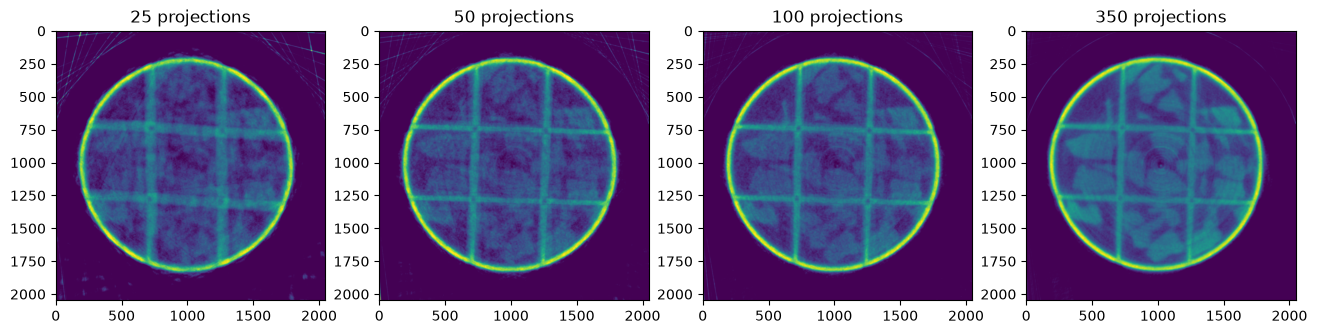

In [53]:
fig, axes = plt.subplots(1,len(recons),figsize=(4*len(recons),5))

vmin=0.0
vmax=0.003

for ax, img, ndir in zip(axes,recons,ndirs) :
    ax.imshow(img,vmin=vmin,vmax=vmax)
    ax.set_title(f'{ndir} projections')

plt.savefig('IterativeRecon_SIRT-TV.pdf')